# 06 - Landscape Metrics

Characterises changes in the spatial structure of inundated areas using connected component analysis.

**Methods:**
- Seasonal water masks: wet season (Jun\u2013Oct) and dry season (Dec\u2013Apr)
- Mean seasonal inundation probability, threshold at 0.5
- Connected components (8-connectivity) restricted to OSM wetland boundary
- Patch metrics: n_patches, total area, largest patch, mean patch size, LPI
- Seasonal amplitude per pixel; Wilcoxon signed-rank test pre vs post

**Inputs:** `inundation_cube.nc`, `breakpoint.json`, `wetland_mask.tif`

In [1]:
import scipy.stats
import numpy as np
import pandas as pd
import xarray as xr
import rasterio
import json
from scipy import ndimage as ndi
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'figure.dpi': 300,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

PROCESSED_DIR = Path('data/processed')
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

ANALYSIS_START = '2019-01'
ANALYSIS_END = '2024-12'

# Season definitions (months)
WET_MONTHS = [6, 7, 8, 9, 10]     # Jun–Oct
DRY_MONTHS = [12, 1, 2, 3, 4]     # Dec–Apr

In [2]:
# Load inundation cube
inundation_cube = xr.open_dataarray(PROCESSED_DIR / 'inundation_cube.nc')
inundation_cube = inundation_cube.sel(time=slice(ANALYSIS_START, ANALYSIS_END))

# Load wetland mask
with rasterio.open('data/raw/wetland_mask.tif') as src:
    mask_arr = src.read(1)
wetland_mask_np = mask_arr == 1

wetland_mask = xr.DataArray(wetland_mask_np, dims=['y', 'x'],
                             coords={'y': inundation_cube.y, 'x': inundation_cube.x})

# Load breakpoint
with open(PROCESSED_DIR / 'breakpoint.json') as f:
    bp_data = json.load(f)
breakpoint_date = pd.Timestamp(bp_data['primary_breakpoint'])

# Split into pre/post
pre_cube = inundation_cube.sel(time=inundation_cube.time < np.datetime64(breakpoint_date))
post_cube = inundation_cube.sel(time=inundation_cube.time >= np.datetime64(breakpoint_date))

print(f"Breakpoint: {breakpoint_date.strftime('%Y-%m')}")
print(f"Pre: {len(pre_cube.time)} months, Post: {len(post_cube.time)} months")
print(f"Wetland pixels: {wetland_mask_np.sum():,}")

Breakpoint: 2021-06
Pre: 29 months, Post: 43 months
Wetland pixels: 103,682


## Seasonal Inundation Probability

In [3]:
def seasonal_inund_prob(cube, months, mask_np):
    """
    Mean inundation probability for specified months within wetland mask.
    Returns 2D array: fraction of time steps in those months that pixel was inundated.
    Values NaN outside mask.
    """
    times = pd.DatetimeIndex(cube.time.values)
    month_mask = np.isin(times.month, months)
    subset = cube.isel(time=month_mask)
    
    valid = (subset >= 0).values  # shape (t, y, x)
    water = (subset == 1).values
    
    n_valid = valid.sum(axis=0).astype(float)
    n_water = water.sum(axis=0).astype(float)
    
    prob = np.where(n_valid > 0, n_water / n_valid, np.nan)
    prob[~mask_np] = np.nan
    return prob

# Compute for all 4 combinations
pre_wet_prob   = seasonal_inund_prob(pre_cube,  WET_MONTHS, wetland_mask_np)
pre_dry_prob   = seasonal_inund_prob(pre_cube,  DRY_MONTHS, wetland_mask_np)
post_wet_prob  = seasonal_inund_prob(post_cube, WET_MONTHS, wetland_mask_np)
post_dry_prob  = seasonal_inund_prob(post_cube, DRY_MONTHS, wetland_mask_np)

print("Mean seasonal inundation probability (wetland pixels):")
print(f"  Pre  wet:  {np.nanmean(pre_wet_prob):.3f}")
print(f"  Pre  dry:  {np.nanmean(pre_dry_prob):.3f}")
print(f"  Post wet:  {np.nanmean(post_wet_prob):.3f}")
print(f"  Post dry:  {np.nanmean(post_dry_prob):.3f}")

Mean seasonal inundation probability (wetland pixels):
  Pre  wet:  0.187
  Pre  dry:  0.201
  Post wet:  0.296
  Post dry:  0.270


## Connected Component Analysis

In [4]:
def compute_patch_metrics(prob_map, threshold=0.5, connectivity=2):
    """
    Binary water mask at threshold, then 8-connected labelling.
    Returns dict of patch metrics (restricted to non-NaN pixels).
    connectivity=2 \u2192 8-connectivity in scipy.ndimage
    """
    binary = (prob_map >= threshold).astype(np.uint8)
    binary[np.isnan(prob_map)] = 0  # exclude nodata
    
    structure = ndi.generate_binary_structure(2, connectivity)
    labeled, n_patches = ndi.label(binary, structure=structure)
    
    if n_patches == 0:
        return {'n_patches': 0, 'total_water_px': 0,
                'largest_patch_px': 0, 'mean_patch_px': np.nan, 'lpi': np.nan}
    
    patch_sizes = np.bincount(labeled.ravel())[1:]  # skip label 0 (background)
    total_water = patch_sizes.sum()
    largest = patch_sizes.max()
    
    return {
        'n_patches': n_patches,
        'total_water_px': int(total_water),
        'largest_patch_px': int(largest),
        'mean_patch_px': float(patch_sizes.mean()),
        'lpi': float(largest / total_water * 100) if total_water > 0 else np.nan,
        'labeled': labeled,
        'binary': binary,
    }

results = {}
for period, wet_prob, dry_prob, label in [
    ('pre',  pre_wet_prob,  pre_dry_prob,  'Pre'),
    ('post', post_wet_prob, post_dry_prob, 'Post'),
]:
    for season, prob in [('wet', wet_prob), ('dry', dry_prob)]:
        key = f'{period}_{season}'
        m = compute_patch_metrics(prob)
        results[key] = m
        print(f"{label} {season}: n_patches={m['n_patches']}, "
              f"total={m['total_water_px']:,} px, "
              f"largest={m['largest_patch_px']:,} px, "
              f"LPI={m['lpi']:.1f}%")

Pre wet: n_patches=131, total=20,289 px, largest=7,921 px, LPI=39.0%
Pre dry: n_patches=102, total=20,360 px, largest=9,769 px, LPI=48.0%
Post wet: n_patches=131, total=27,218 px, largest=9,355 px, LPI=34.4%
Post dry: n_patches=126, total=23,430 px, largest=9,483 px, LPI=40.5%


In [5]:
# Summary table
rows = []
for period in ['pre', 'post']:
    for season in ['wet', 'dry']:
        key = f'{period}_{season}'
        m = results[key]
        rows.append({
            'Period': period.capitalize(),
            'Season': season.capitalize(),
            'N Patches': m['n_patches'],
            'Total Water (px)': m['total_water_px'],
            'Largest Patch (px)': m['largest_patch_px'],
            'Mean Patch (px)': f"{m['mean_patch_px']:.1f}" if not np.isnan(m.get('mean_patch_px', np.nan)) else 'N/A',
            'LPI (%)': f"{m['lpi']:.1f}" if not np.isnan(m.get('lpi', np.nan)) else 'N/A',
        })

df_metrics = pd.DataFrame(rows)
print("\nLandscape Metrics Summary:")
print(df_metrics.to_string(index=False))


Landscape Metrics Summary:
Period Season  N Patches  Total Water (px)  Largest Patch (px) Mean Patch (px) LPI (%)
   Pre    Wet        131             20289                7921           154.9    39.0
   Pre    Dry        102             20360                9769           199.6    48.0
  Post    Wet        131             27218                9355           207.8    34.4
  Post    Dry        126             23430                9483           186.0    40.5


## Figure 1 — Seasonal Water Masks and Patch Structure

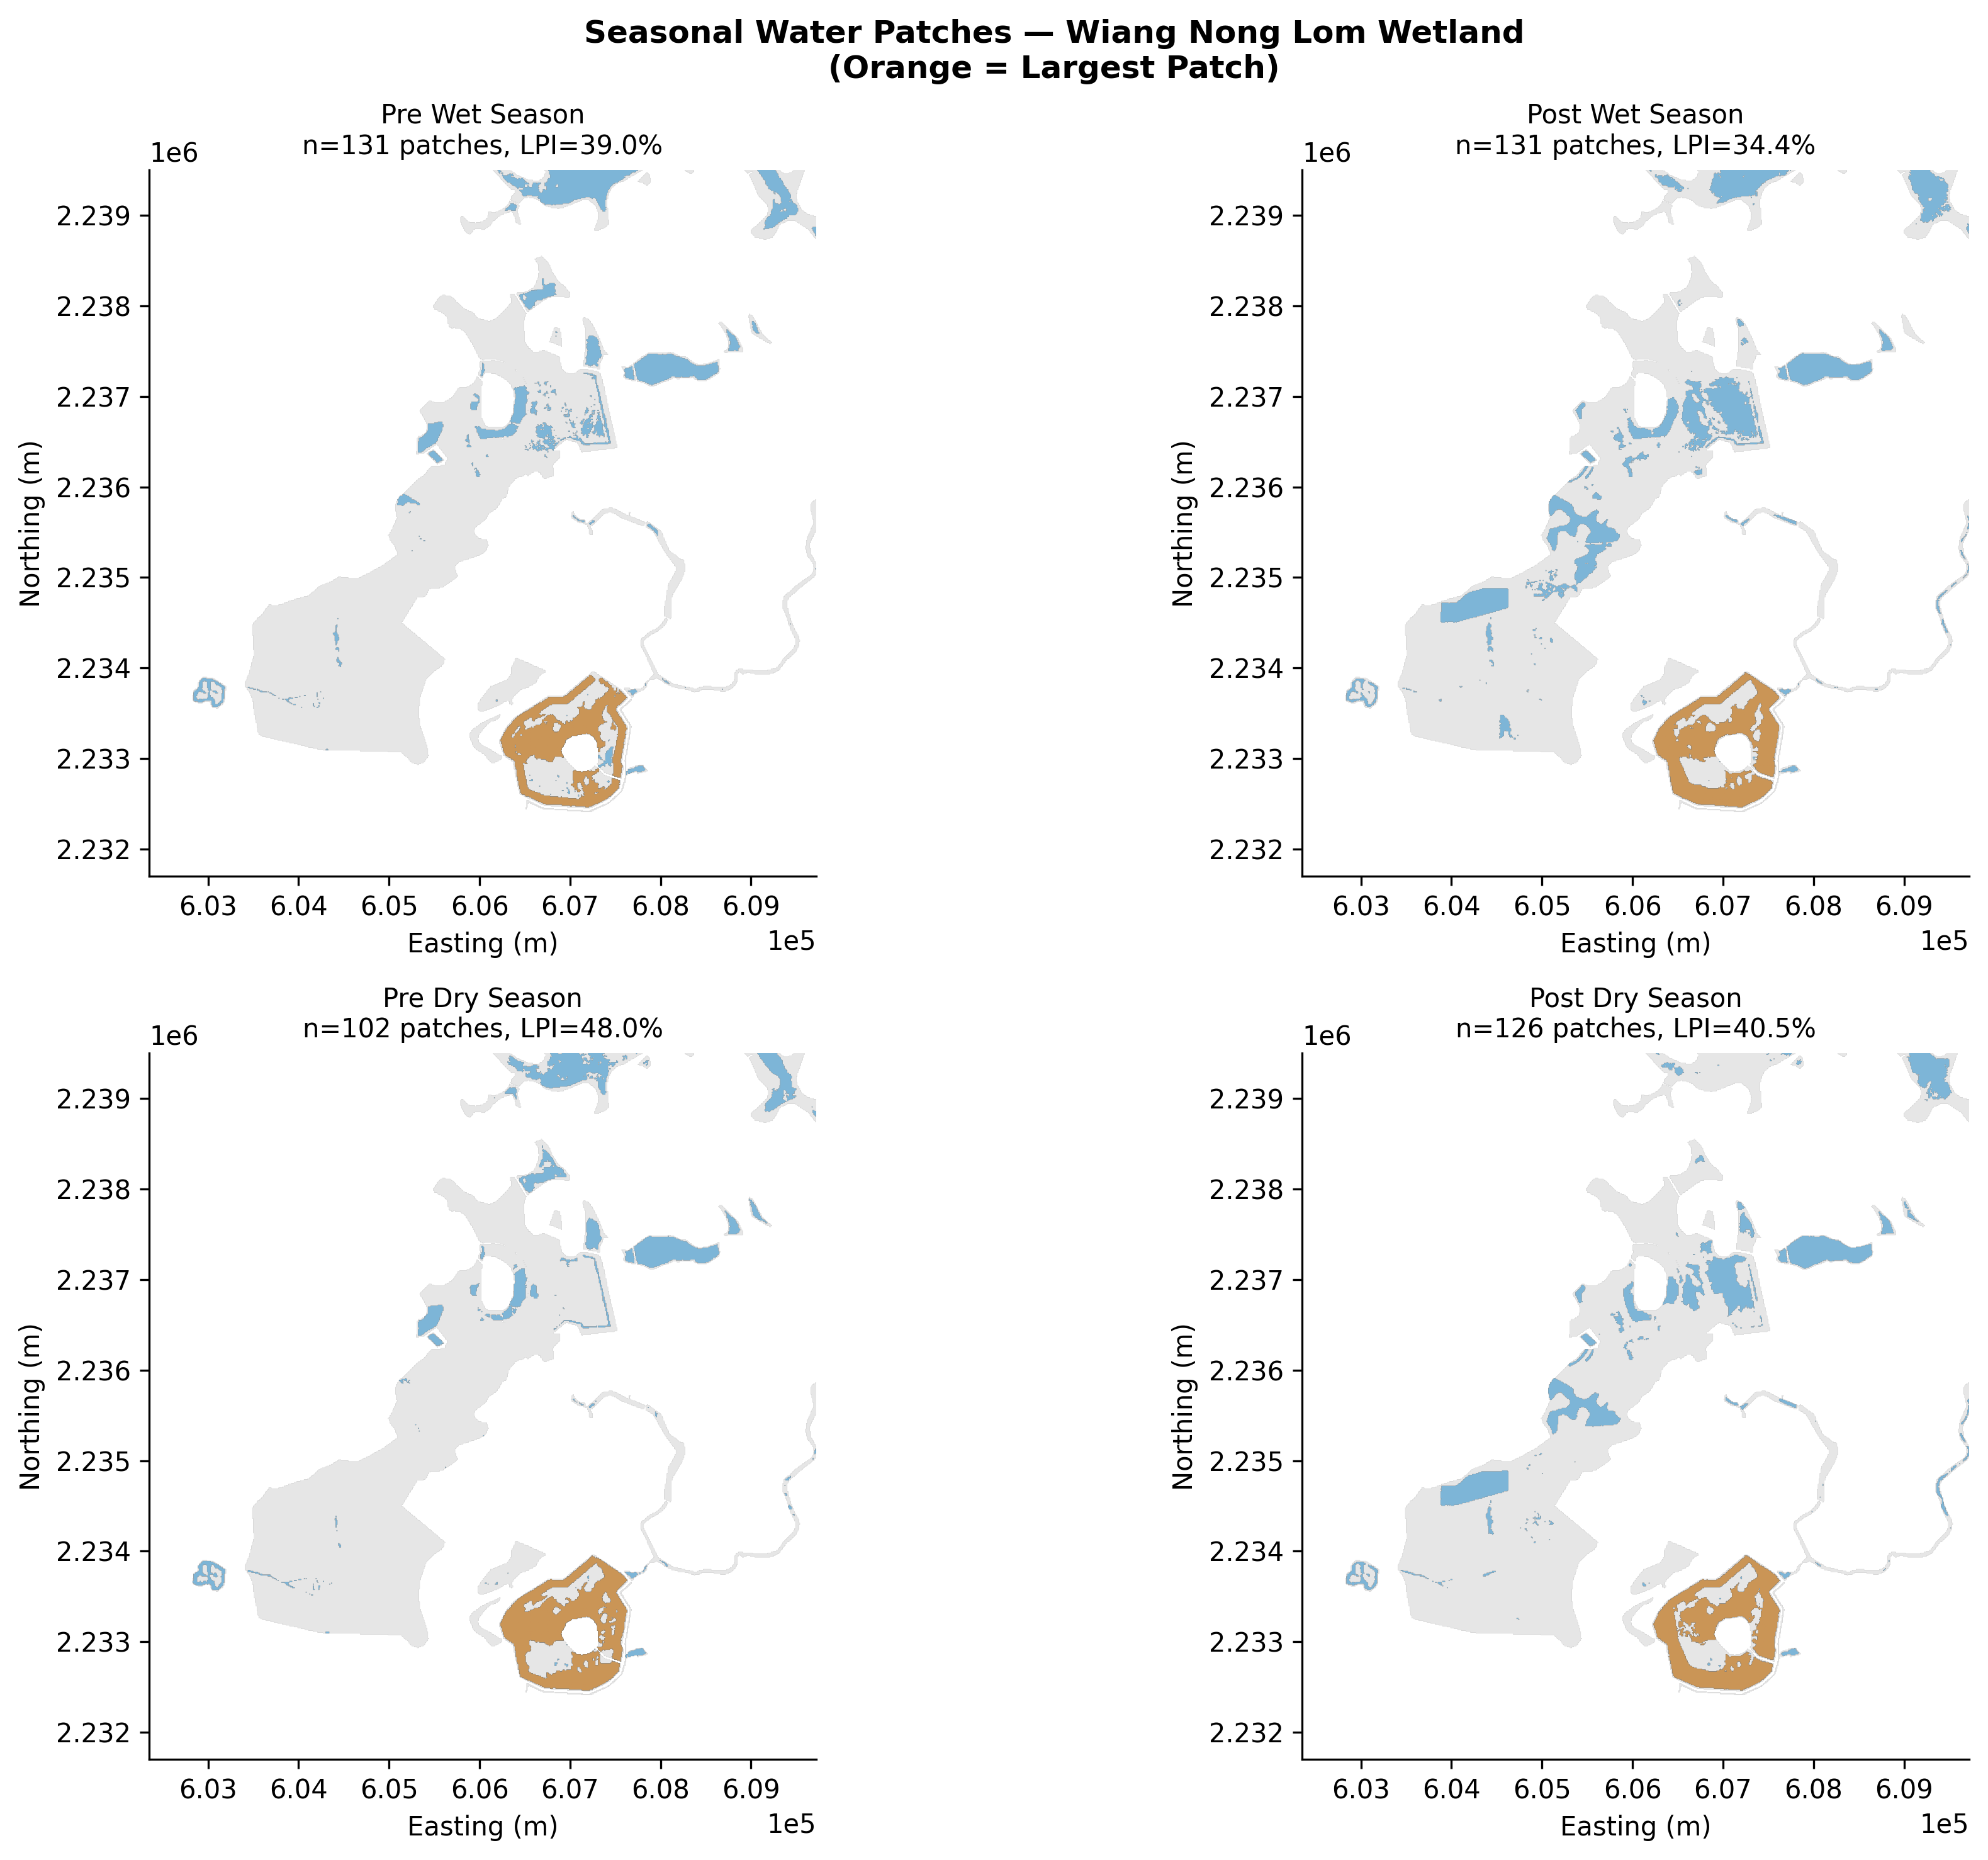

Saved: outputs/fig_10_patch_maps.pdf/.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

def get_extent_from_cube(cube):
    x = cube.x.values; y = cube.y.values
    dx = abs(x[1]-x[0])/2; dy = abs(y[1]-y[0])/2
    return [x[0]-dx, x[-1]+dx, y[-1]-dy, y[0]+dy]

ext = get_extent_from_cube(inundation_cube)
titles = [('Pre Wet Season', 'pre_wet'), ('Post Wet Season', 'post_wet'),
          ('Pre Dry Season', 'pre_dry'), ('Post Dry Season', 'post_dry')]

for ax, (title, key) in zip(axes.flat, titles):
    m = results[key]
    labeled = m.get('labeled', np.zeros_like(wetland_mask_np, dtype=int))
    binary = m.get('binary', np.zeros_like(wetland_mask_np, dtype=np.uint8))
    
    # Background: wetland extent (grey)
    bg = np.where(wetland_mask_np, 0.3, np.nan)
    ax.imshow(bg, cmap='Greys', vmin=0, vmax=1, extent=ext, origin='upper', aspect='equal', alpha=0.5)
    
    # Water pixels (blue)
    water_display = np.where(binary.astype(bool), 1.0, np.nan)
    ax.imshow(water_display, cmap='Blues', vmin=0.5, vmax=1.5,
              extent=ext, origin='upper', aspect='equal', alpha=0.85)
    
    # Largest patch outline
    if m['n_patches'] > 0:
        lbl_counts = np.bincount(labeled.ravel())[1:]
        largest_label = np.argmax(lbl_counts) + 1
        largest_mask = (labeled == largest_label).astype(float)
        largest_mask[largest_mask == 0] = np.nan
        ax.imshow(largest_mask, cmap='autumn', vmin=0.5, vmax=1.5,
                  extent=ext, origin='upper', aspect='equal', alpha=0.6)
    
    ax.set_title(f'{title}\nn={m["n_patches"]} patches, LPI={m["lpi"]:.1f}%', fontsize=10)
    ax.set_xlabel('Easting (m)')
    ax.set_ylabel('Northing (m)')
    ax.ticklabel_format(style='sci', axis='both', scilimits=(0,0))

plt.suptitle('Seasonal Water Patches \u2014 Wiang Nong Lom Wetland\n(Orange = Largest Patch)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_10_patch_maps.pdf', bbox_inches='tight')
plt.savefig(OUTPUT_DIR / 'fig_10_patch_maps.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: outputs/fig_10_patch_maps.pdf/.png")

## Figure 2 — Landscape Metric Comparison

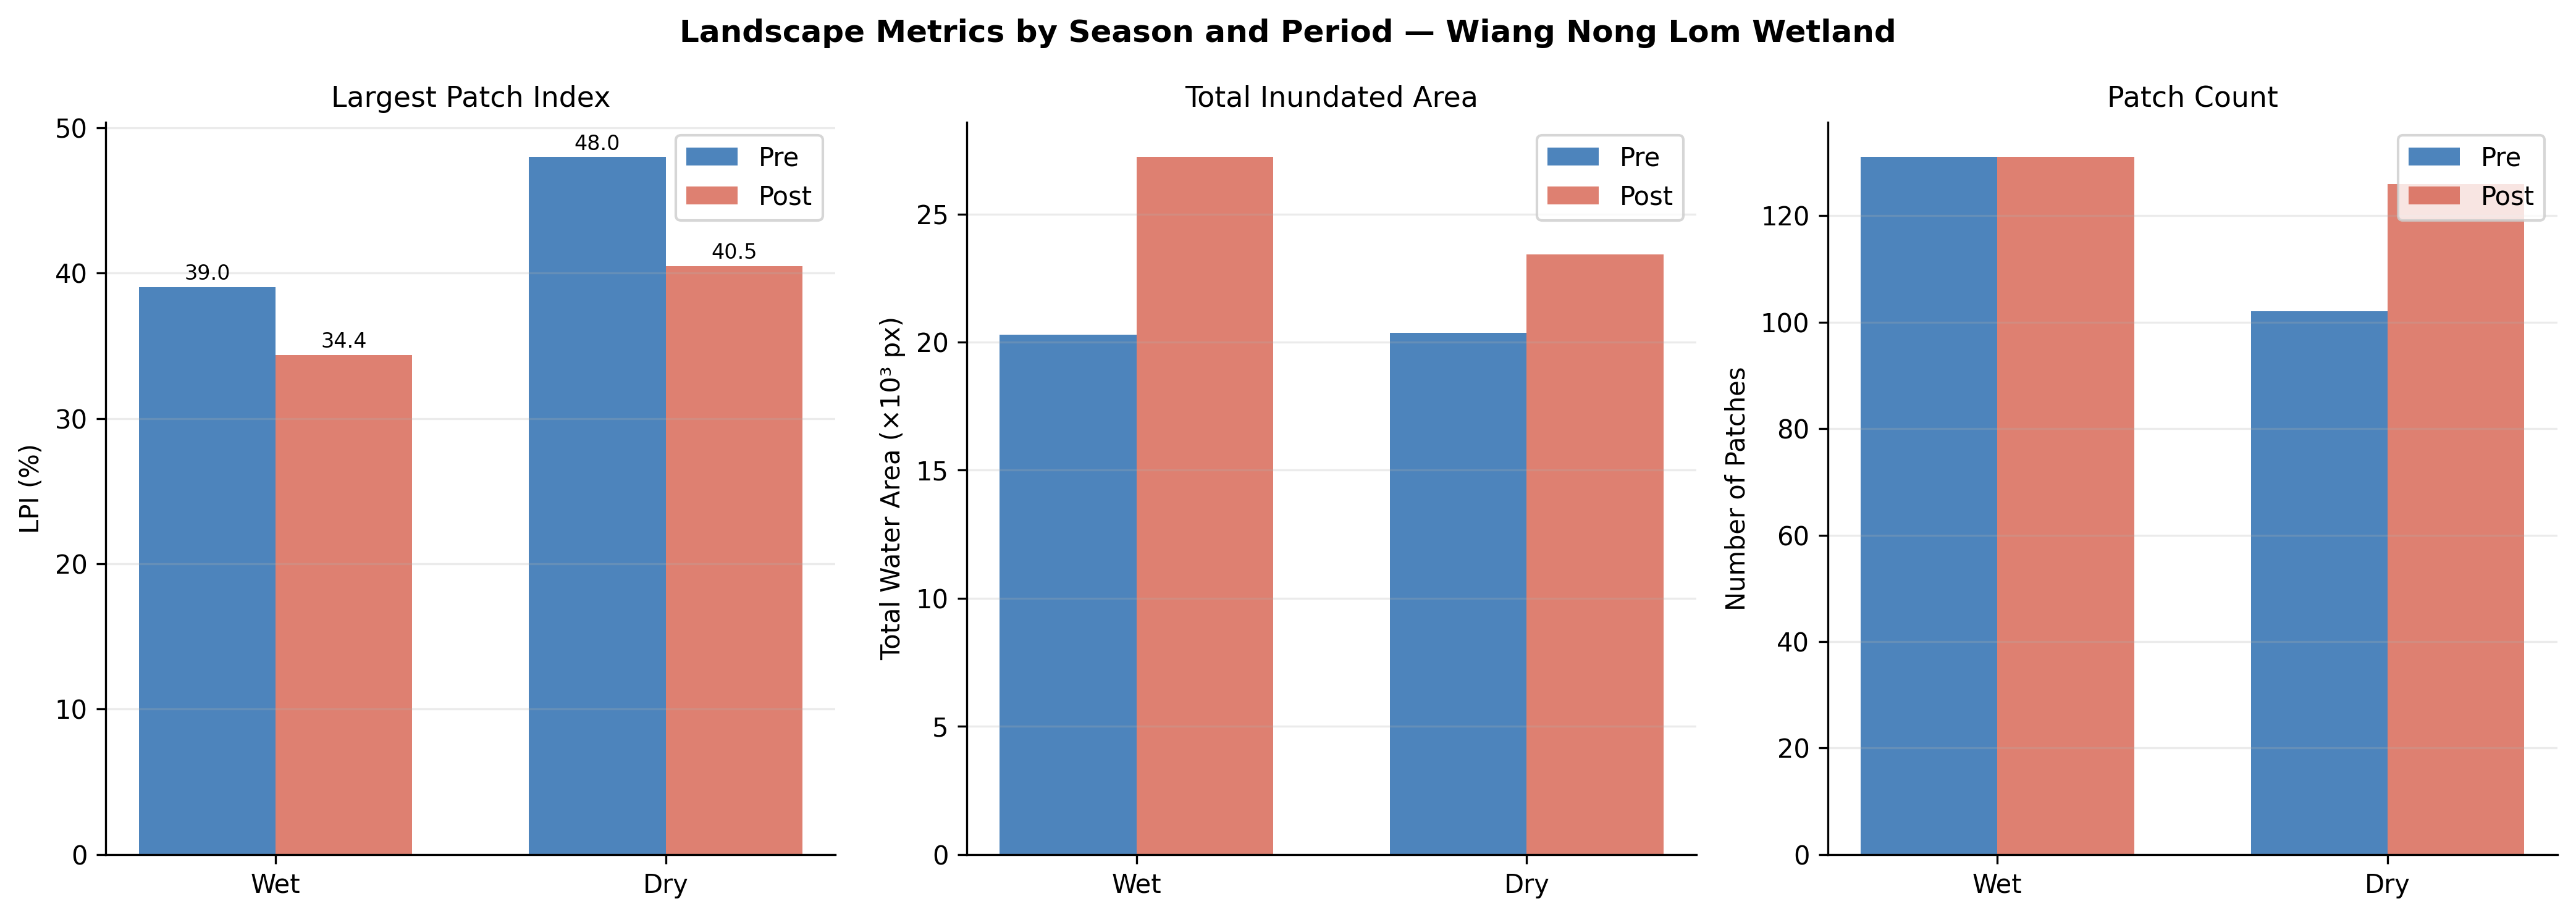

Saved: outputs/fig_06_landscape_metrics.pdf/.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

seasons = ['Wet', 'Dry']
x = np.arange(len(seasons))
width = 0.35
colors_p = ['#2166ac', '#d6604d']

# LPI
ax = axes[0]
lpi_pre  = [results[f'pre_{s.lower()}']['lpi']  for s in seasons]
lpi_post = [results[f'post_{s.lower()}']['lpi'] for s in seasons]
bars1 = ax.bar(x - width/2, lpi_pre,  width, label='Pre',  color=colors_p[0], alpha=0.8)
bars2 = ax.bar(x + width/2, lpi_post, width, label='Post', color=colors_p[1], alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(seasons)
ax.set_ylabel('LPI (%)')
ax.set_title('Largest Patch Index')
ax.legend(); ax.grid(True, alpha=0.25, axis='y')
for bar in bars1: ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{bar.get_height():.1f}', ha='center', fontsize=8)
for bar in bars2: ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{bar.get_height():.1f}', ha='center', fontsize=8)

# Total water area
ax = axes[1]
tw_pre  = [results[f'pre_{s.lower()}']['total_water_px']  / 1000 for s in seasons]
tw_post = [results[f'post_{s.lower()}']['total_water_px'] / 1000 for s in seasons]
bars1 = ax.bar(x - width/2, tw_pre,  width, label='Pre',  color=colors_p[0], alpha=0.8)
bars2 = ax.bar(x + width/2, tw_post, width, label='Post', color=colors_p[1], alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(seasons)
ax.set_ylabel('Total Water Area (\u00d710\u00b3 px)')
ax.set_title('Total Inundated Area')
ax.legend(); ax.grid(True, alpha=0.25, axis='y')

# Number of patches
ax = axes[2]
np_pre  = [results[f'pre_{s.lower()}']['n_patches']  for s in seasons]
np_post = [results[f'post_{s.lower()}']['n_patches'] for s in seasons]
bars1 = ax.bar(x - width/2, np_pre,  width, label='Pre',  color=colors_p[0], alpha=0.8)
bars2 = ax.bar(x + width/2, np_post, width, label='Post', color=colors_p[1], alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(seasons)
ax.set_ylabel('Number of Patches')
ax.set_title('Patch Count')
ax.legend(); ax.grid(True, alpha=0.25, axis='y')

plt.suptitle('Landscape Metrics by Season and Period \u2014 Wiang Nong Lom Wetland', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_06_landscape_metrics.pdf', bbox_inches='tight')
plt.savefig(OUTPUT_DIR / 'fig_06_landscape_metrics.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: outputs/fig_06_landscape_metrics.pdf/.png")

## Seasonal Amplitude and Wilcoxon Test

In [8]:
# Per-pixel seasonal amplitude = |wet_prob - dry_prob|
pre_amplitude  = np.abs(pre_wet_prob  - pre_dry_prob)
post_amplitude = np.abs(post_wet_prob - post_dry_prob)

# Restrict to pixels valid in BOTH periods
valid_both     = wetland_mask_np & ~np.isnan(pre_amplitude) & ~np.isnan(post_amplitude)
pre_amp_valid  = pre_amplitude[valid_both]
post_amp_valid = post_amplitude[valid_both]

print(f"Valid pixels for amplitude comparison: {valid_both.sum():,}")
print(f"Pre  amplitude: mean={pre_amp_valid.mean():.3f}, median={np.median(pre_amp_valid):.3f}")
print(f"Post amplitude: mean={post_amp_valid.mean():.3f}, median={np.median(post_amp_valid):.3f}")

# Wilcoxon signed-rank test (paired pixels)
stat, p_val = wilcoxon(post_amp_valid, pre_amp_valid, alternative="two-sided")

# Rank-biserial correlation (effect size for Wilcoxon signed-rank test)
# r_rb = (W+ - W-) / (W+ + W-)  where W+ + W- = n*(n+1)/2
diffs        = post_amp_valid - pre_amp_valid
diffs_nz     = diffs[diffs != 0]              # exclude zero differences
n_nz         = len(diffs_nz)
ranks        = scipy.stats.rankdata(np.abs(diffs_nz))
W_plus       = ranks[diffs_nz > 0].sum()
W_minus      = ranks[diffs_nz < 0].sum()
r_rb         = (W_plus - W_minus) / (W_plus + W_minus)

def effect_label(r):
    r = abs(r)
    if r < 0.1:  return "negligible"
    if r < 0.3:  return "small"
    if r < 0.5:  return "medium"
    return "large"

print(f"\nWilcoxon signed-rank test (post vs pre amplitude):")
print(f"  W = {stat:.2f}, p = {p_val:.4e}")
print(f"  {'Significant' if p_val < 0.05 else 'Not significant'} at p < 0.05")
print(f"\nEffect size (rank-biserial correlation):")
print(f"  r_rb = {r_rb:.3f}  ({effect_label(r_rb)})")
print(f"  n non-zero differences = {n_nz:,}")
print(f"  Interpretation: post-intervention amplitude is "
      f"{'higher' if r_rb > 0 else 'lower'} than pre ({effect_label(r_rb)} practical effect)")

Valid pixels for amplitude comparison: 103,682
Pre  amplitude: mean=0.068, median=0.000
Post amplitude: mean=0.080, median=0.025

Wilcoxon signed-rank test (post vs pre amplitude):
  W = 1035858452.50, p = 6.4795e-256
  Significant at p < 0.05

Effect size (rank-biserial correlation):
  r_rb = 0.149  (small)
  n non-zero differences = 69,791
  Interpretation: post-intervention amplitude is higher than pre (small practical effect)


## Figure 3 — Seasonal Amplitude Distribution

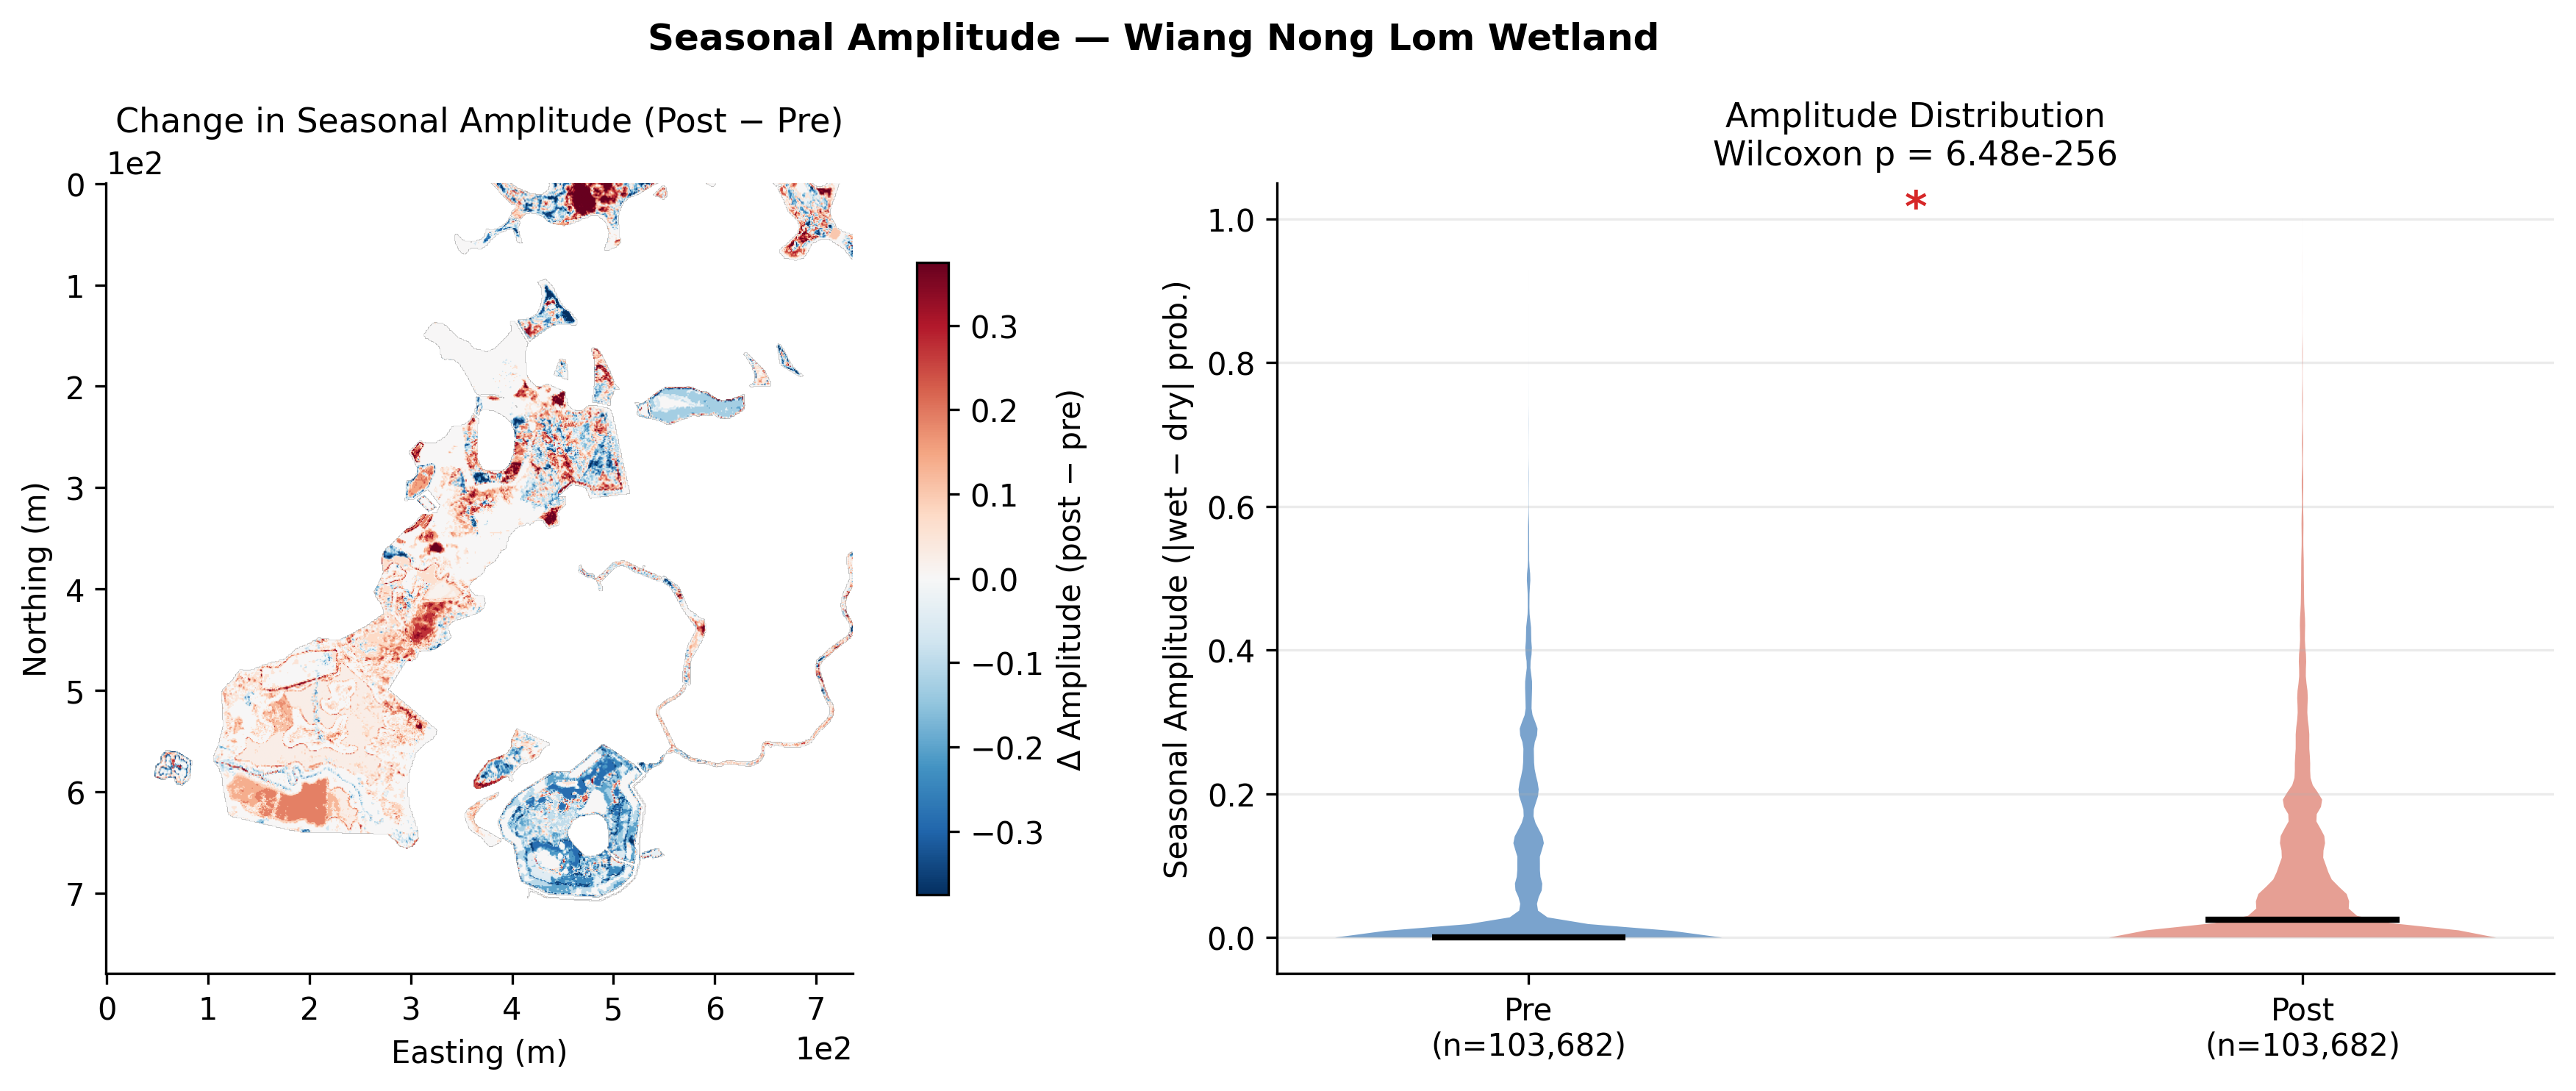

Saved: outputs/fig_11_seasonal_amplitude.pdf/.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: spatial map of amplitude change
amp_diff = post_amplitude - pre_amplitude
amp_diff[~wetland_mask_np] = np.nan
max_v = np.nanpercentile(np.abs(amp_diff), 98)

ext = [inundation_cube.x.values[0], inundation_cube.x.values[-1],
       inundation_cube.y.values[-1], inundation_cube.y.values[0]]

im = axes[0].imshow(amp_diff, cmap='RdBu_r', vmin=-max_v, vmax=max_v,
                     origin='upper', aspect='equal')
plt.colorbar(im, ax=axes[0], label='\u0394 Amplitude (post \u2212 pre)', shrink=0.8)
axes[0].set_title('Change in Seasonal Amplitude (Post \u2212 Pre)')
axes[0].set_xlabel('Easting (m)')
axes[0].set_ylabel('Northing (m)')
axes[0].ticklabel_format(style='sci', axis='both', scilimits=(0,0))

# Right: violin / distribution comparison
parts = axes[1].violinplot([pre_amp_valid, post_amp_valid],
                            positions=[1, 2], showmedians=True, showextrema=False)
for pc, col in zip(parts['bodies'], ['#2166ac', '#d6604d']):
    pc.set_facecolor(col)
    pc.set_alpha(0.6)
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(2)

axes[1].set_xticks([1, 2])
axes[1].set_xticklabels([f'Pre\n(n={len(pre_amp_valid):,})', f'Post\n(n={len(post_amp_valid):,})'])
axes[1].set_ylabel('Seasonal Amplitude (|wet \u2212 dry| prob.)')
axes[1].set_title(f'Amplitude Distribution\nWilcoxon p = {p_val:.2e}')
axes[1].grid(True, alpha=0.25, axis='y')
axes[1].text(1.5, axes[1].get_ylim()[1] * 0.95,
             f'{"*" if p_val < 0.05 else "n.s."}',
             ha='center', fontsize=14, fontweight='bold',
             color='#d62728' if p_val < 0.05 else 'grey')

plt.suptitle('Seasonal Amplitude \u2014 Wiang Nong Lom Wetland', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_11_seasonal_amplitude.pdf', bbox_inches='tight')
plt.savefig(OUTPUT_DIR / 'fig_11_seasonal_amplitude.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: outputs/fig_11_seasonal_amplitude.pdf/.png")

In [10]:
print("\n" + "="*60)
print("LANDSCAPE METRICS SUMMARY \u2014 WIANG NONG LOM WETLAND")
print("="*60)
print(df_metrics.to_string(index=False))
print(f"\nSeasonal Amplitude Wilcoxon test: W={stat:.2f}, p={p_val:.4e}")
print(f"Pre  mean amplitude: {pre_amp_valid.mean():.3f}")
print(f"Post mean amplitude: {post_amp_valid.mean():.3f}")
print(f"Change: {(post_amp_valid.mean()-pre_amp_valid.mean()):+.3f}")


LANDSCAPE METRICS SUMMARY — WIANG NONG LOM WETLAND
Period Season  N Patches  Total Water (px)  Largest Patch (px) Mean Patch (px) LPI (%)
   Pre    Wet        131             20289                7921           154.9    39.0
   Pre    Dry        102             20360                9769           199.6    48.0
  Post    Wet        131             27218                9355           207.8    34.4
  Post    Dry        126             23430                9483           186.0    40.5

Seasonal Amplitude Wilcoxon test: W=1035858452.50, p=6.4795e-256
Pre  mean amplitude: 0.068
Post mean amplitude: 0.080
Change: +0.011


## Summary

**Key outputs:**
- `outputs/fig_10_patch_maps.pdf/png` \u2014 Seasonal water patch maps with largest patch highlighted
- `outputs/fig_06_landscape_metrics.pdf/png` \u2014 LPI, total area, patch count by season
- `outputs/fig_11_seasonal_amplitude.pdf/png` \u2014 Per-pixel amplitude change and distribution

**Interpretation:**
- LPI increase \u2192 inundation consolidating into fewer, larger connected patches
- LPI decrease with total area increase \u2192 new water emerging as dispersed patches
- Wilcoxon p < 0.05 \u2192 statistically significant change in seasonal variability

Analysis complete.